# When Trends Become Policy: Measuring the Influence of Social Media on Consumer Goods and Regulation

**Authors:** Hanyu Xie (hx2413), Haotian Lei (hl3945)

This notebook analyzes how large online trends on Chinese social media platforms translate into real-world market shifts and policy responses through two case studies:

1. **Nongfu Spring Public Opinion Crisis** (Jan - Sep 2024)
2. **Japan Nuclear Wastewater Salt Panic** (Jul - Oct 2023)

## 1. Setup and Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats
from statsmodels.tsa.stattools import grangercausalitytests, adfuller
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (14, 7)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
sns.set_style('whitegrid')

import os
os.makedirs('figures', exist_ok=True)
print('All imports successful.')

All imports successful.


## 2. Data Loading

| Source | Description |
|--------|-------------|
| [Investing.com](https://www.investing.com/) | Historical daily OHLCV stock prices |
| [Google Trends](https://trends.google.com/) | Weekly search interest index (0-100) |
| Event timeline (xlsx) | Key events from financial news and government sources |

In [2]:
def parse_volume(v):
    if pd.isna(v) or v == '-':
        return 0
    v = str(v).strip().replace(',', '')
    for suffix, mult in {'K': 1e3, 'M': 1e6, 'B': 1e9}.items():
        if v.endswith(suffix):
            return float(v[:-1]) * mult
    try:
        return float(v)
    except:
        return 0

def load_investing_csv(filepath, name='Stock'):
    df = pd.read_csv(filepath)
    df.columns = df.columns.str.strip().str.replace('\ufeff', '')
    df['date'] = pd.to_datetime(df['Date'])
    df['close'] = df['Price'].astype(str).str.replace(',', '').astype(float)
    for col in ['Open', 'High', 'Low']:
        df[col.lower()] = df[col].astype(str).str.replace(',', '').astype(float)
    df['volume'] = df['Vol.'].apply(parse_volume)
    df = df[['date', 'close', 'open', 'high', 'low', 'volume']].sort_values('date').reset_index(drop=True)
    df['daily_return'] = df['close'].pct_change()
    df['cum_return'] = (1 + df['daily_return']).cumprod() - 1
    print(f"{name}: {len(df)} days, {df['date'].min().date()} to {df['date'].max().date()}, price {df['close'].min():.2f}-{df['close'].max():.2f}")
    return df

def load_gtrends_csv(filepath, name='Trends'):
    df = pd.read_csv(filepath)
    df.columns = df.columns.str.strip().str.replace('"', '')
    date_col = df.columns[0]
    df = df.rename(columns={date_col: 'date'})
    df['date'] = pd.to_datetime(df['date'])
    for col in df.columns[1:]:
        df[col] = pd.to_numeric(df[col].astype(str).str.replace('<1', '0'), errors='coerce')
    df = df.sort_values('date').reset_index(drop=True)
    print(f"{name}: {len(df)} weeks, {df['date'].min().date()} to {df['date'].max().date()}, cols: {list(df.columns[1:])}")
    return df

In [5]:
# Case 1: Nongfu Spring
nongfu_stock = load_investing_csv('data/Nongfu Spring Stock Price History.csv', 'Nongfu Spring (09633.HK)')
nongfu_trends = load_gtrends_csv('data/nongfu_time_series.csv', 'Nongfu Trends')

Nongfu Spring (09633.HK): 184 days, 2024-01-02 to 2024-09-30, price 24.35-47.95
Nongfu Trends: 40 weeks, 2023-12-31 to 2024-09-29, cols: ['Nongfu Spring', 'Wahaha']


In [7]:
# Case 2: Salt Panic
xuetian_stock = load_investing_csv('data/Snowsky Salt Industry Stock Price History.csv', 'Xuetian Salt (600929.SS)')
suyan_stock = load_investing_csv('data/Jiangsu Jingshen Salt & Chemical Stock Price History.csv', 'Suyan Jingshen (603299.SS)')
salt_trends = load_gtrends_csv('data/salt_time_series.csv', 'Salt Panic Trends')

Xuetian Salt (600929.SS): 81 days, 2023-07-03 to 2023-10-31, price 6.02-8.29
Suyan Jingshen (603299.SS): 81 days, 2023-07-03 to 2023-10-31, price 8.36-11.52
Salt Panic Trends: 19 weeks, 2023-06-25 to 2023-10-29, cols: ['Japan nuclear wastewater', 'salt panic']


## 3. Data Alignment

Align daily stock data to weekly Google Trends frequency.

In [8]:
def align_stock_to_weekly(stock_df, trends_df):
    stock_weekly = stock_df.set_index('date').resample('W-SUN').agg(
        {'close': 'mean', 'volume': 'sum', 'daily_return': 'sum'}).reset_index()
    stock_weekly.columns = ['date', 'avg_close', 'total_volume', 'weekly_return']
    merged = pd.merge_asof(trends_df.sort_values('date'), stock_weekly.sort_values('date'),
                           on='date', direction='nearest', tolerance=pd.Timedelta('7D'))
    merged = merged.dropna(subset=['avg_close'])
    print(f"Aligned: {len(merged)} weekly observations")
    return merged

nongfu_merged = align_stock_to_weekly(nongfu_stock, nongfu_trends)
nongfu_tcols = [c for c in nongfu_merged.columns if c not in ['date','avg_close','total_volume','weekly_return']]

salt_merged_x = align_stock_to_weekly(xuetian_stock, salt_trends)
salt_merged_s = align_stock_to_weekly(suyan_stock, salt_trends)
salt_tcols = [c for c in salt_merged_x.columns if c not in ['date','avg_close','total_volume','weekly_return']]

print(f"\nNongfu trend cols: {nongfu_tcols}")
print(f"Salt trend cols: {salt_tcols}")

Aligned: 40 weekly observations
Aligned: 17 weekly observations
Aligned: 17 weekly observations

Nongfu trend cols: ['Nongfu Spring', 'Wahaha']
Salt trend cols: ['Japan nuclear wastewater', 'salt panic']


## 4. Event Timelines

In [9]:
nongfu_events = {
    '2024-02-25': 'Wahaha founder\npasses away',
    '2024-03-03': 'Boycott goes\nviral on Weibo',
    '2024-04-01': 'Green bottle water\nlaunched',
    '2024-05-20': 'Official statement\nrefuting rumors',
    '2024-08-27': 'H1 Report: water\nrevenue -18.3%',
}
nongfu_crisis = (pd.Timestamp('2024-02-25'), pd.Timestamp('2024-06-30'))

salt_events = {
    '2023-08-22': 'Japan confirms\nrelease date',
    '2023-08-24': 'Wastewater released;\nCustoms bans JP imports',
    '2023-08-25': 'China Salt Group:\n"supply sufficient"',
    '2023-09-07': 'Full correction:\nstocks at baseline',
}
salt_panic = (pd.Timestamp('2023-08-22'), pd.Timestamp('2023-08-28'))
print('Event timelines defined.')

Event timelines defined.


## 5. Visualization

### 5.1 Case 1: Nongfu Spring
#### Figure 1: Search Interest vs. Stock Price

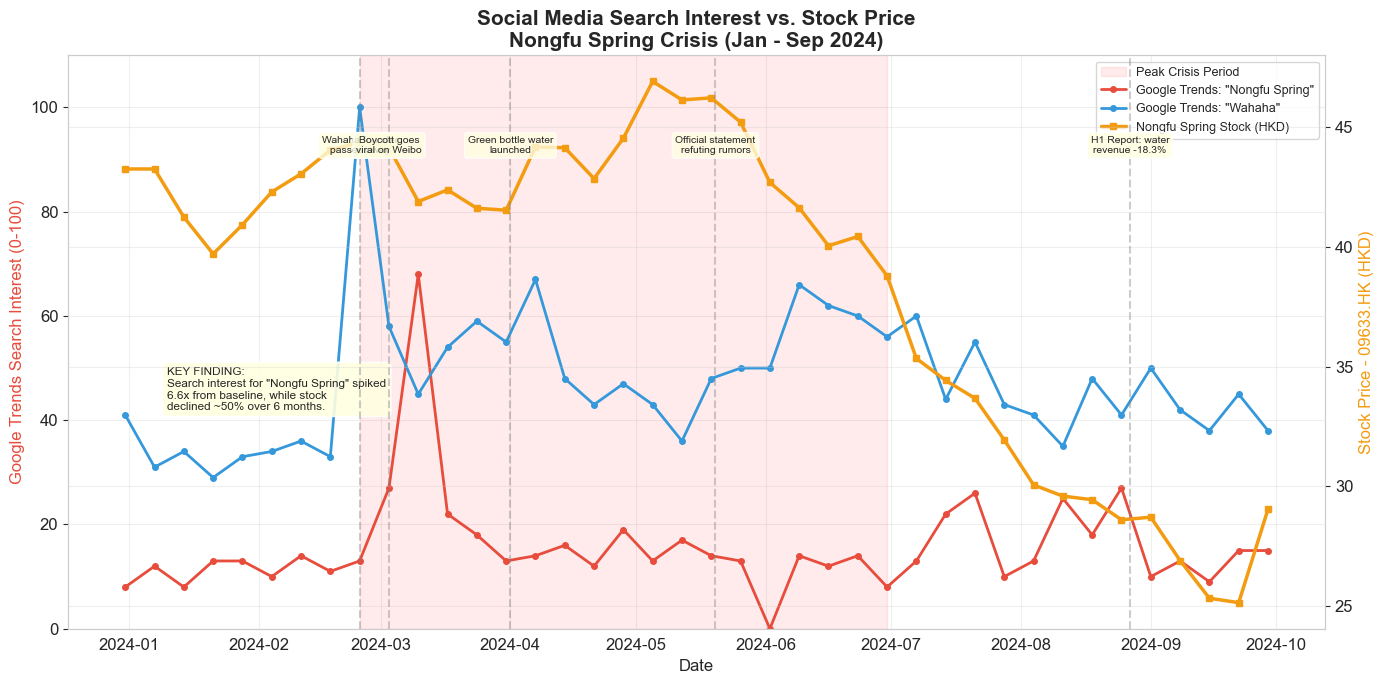

In [10]:
fig, ax1 = plt.subplots(figsize=(14, 7))
ax1.axvspan(*nongfu_crisis, alpha=0.08, color='red', label='Peak Crisis Period')

colors_t = ['#E74C3C', '#3498DB']
for i, col in enumerate(nongfu_tcols[:2]):
    ax1.plot(nongfu_merged['date'], nongfu_merged[col], '-o', color=colors_t[i],
             markersize=4, linewidth=2, label=f'Google Trends: "{col}"')
ax1.set_ylabel('Google Trends Search Interest (0-100)', fontsize=12, color='#E74C3C')
ax1.set_ylim(0, 110)

ax2 = ax1.twinx()
ax2.plot(nongfu_merged['date'], nongfu_merged['avg_close'], '-s', color='#F39C12',
         markersize=4, linewidth=2.5, label='Nongfu Spring Stock (HKD)')
ax2.set_ylabel('Stock Price - 09633.HK (HKD)', fontsize=12, color='#F39C12')

baseline = max(1, nongfu_merged[nongfu_tcols[0]].iloc[:4].mean())
peak_interest = nongfu_merged[nongfu_tcols[0]].max()
ax1.annotate(f'KEY FINDING:\nSearch interest for "{nongfu_tcols[0]}" spiked\n{peak_interest/baseline:.1f}x from baseline, while stock\ndeclined ~50% over 6 months.',
            xy=(pd.Timestamp('2024-01-10'), 42), fontsize=8.5,
            bbox=dict(boxstyle='round,pad=0.4', facecolor='lightyellow', alpha=0.9))

for ds, label in nongfu_events.items():
    dt = pd.Timestamp(ds)
    ax2.axvline(x=dt, color='gray', linestyle='--', alpha=0.4)
    ax2.annotate(label, xy=(dt, ax2.get_ylim()[1]*0.93), fontsize=7.5, ha='center', va='top',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', alpha=0.8))

h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1+h2, l1+l2, loc='upper right', fontsize=9)
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax1.xaxis.set_major_locator(mdates.MonthLocator())
ax1.set_xlabel('Date')
plt.title('Social Media Search Interest vs. Stock Price\nNongfu Spring Crisis (Jan - Sep 2024)', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/Fig1_NongfuSpring_Trends_vs_Stock.png', dpi=150, bbox_inches='tight')
plt.show()

#### Figure 2: Stock Price & Volume

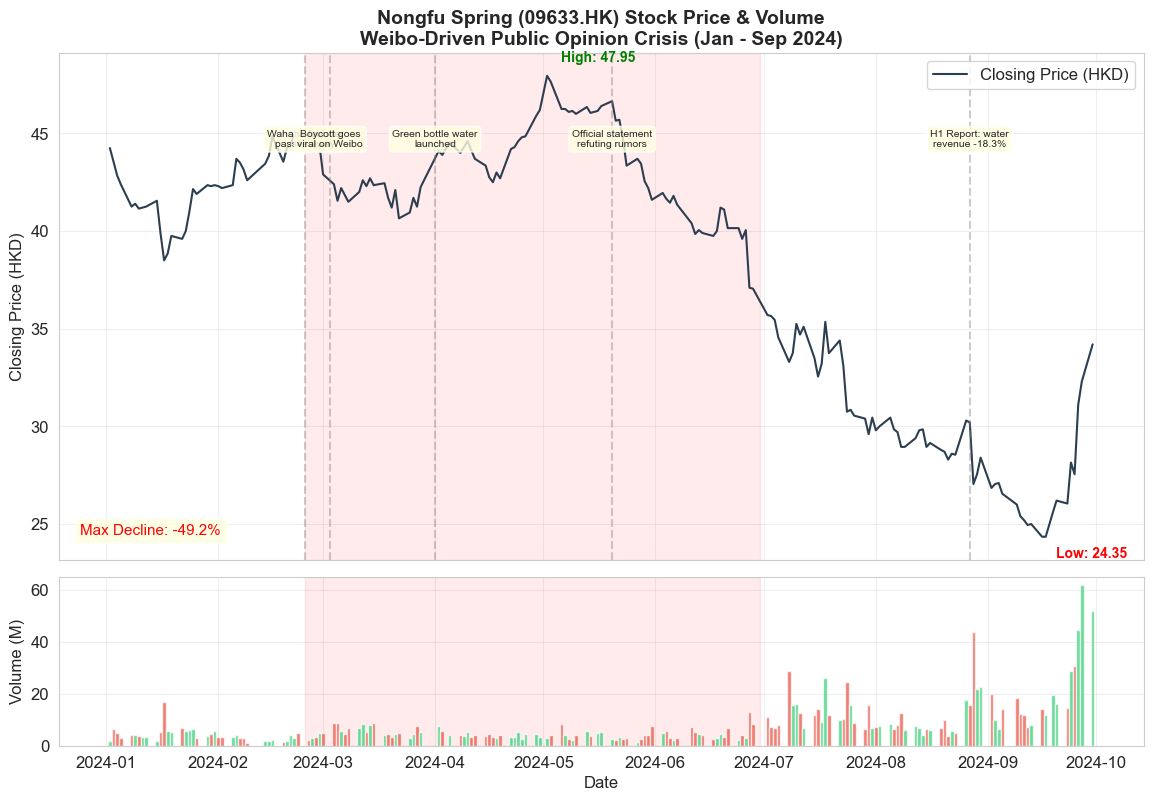

In [11]:
fig, (ax_p, ax_v) = plt.subplots(2, 1, figsize=(14, 9), height_ratios=[3,1], sharex=True, gridspec_kw={'hspace':0.05})
for ax in [ax_p, ax_v]: ax.axvspan(*nongfu_crisis, alpha=0.08, color='red')

ax_p.plot(nongfu_stock['date'], nongfu_stock['close'], color='#2C3E50', linewidth=1.5, label='Closing Price (HKD)')
mi, mx = nongfu_stock['close'].idxmin(), nongfu_stock['close'].idxmax()
ax_p.annotate(f"High: {nongfu_stock.loc[mx,'close']:.2f}", xy=(nongfu_stock.loc[mx,'date'], nongfu_stock.loc[mx,'close']),
             xytext=(10,10), textcoords='offset points', fontsize=10, color='green', fontweight='bold')
ax_p.annotate(f"Low: {nongfu_stock.loc[mi,'close']:.2f}", xy=(nongfu_stock.loc[mi,'date'], nongfu_stock.loc[mi,'close']),
             xytext=(10,-15), textcoords='offset points', fontsize=10, color='red', fontweight='bold')
decline = (nongfu_stock['close'].min()-nongfu_stock['close'].max())/nongfu_stock['close'].max()*100
ax_p.text(0.02, 0.05, f'Max Decline: {decline:.1f}%', transform=ax_p.transAxes, fontsize=11, color='red',
         bbox=dict(facecolor='lightyellow', alpha=0.8))
for ds, label in nongfu_events.items():
    dt = pd.Timestamp(ds)
    ax_p.axvline(x=dt, color='gray', linestyle='--', alpha=0.4)
    ax_p.annotate(label, xy=(dt, ax_p.get_ylim()[1]*0.92), fontsize=7.5, ha='center', va='top',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', alpha=0.8))
ax_p.set_ylabel('Closing Price (HKD)'); ax_p.legend(loc='upper right')

colors_v = ['#E74C3C' if r<0 else '#2ECC71' for r in nongfu_stock['daily_return'].fillna(0)]
ax_v.bar(nongfu_stock['date'], nongfu_stock['volume']/1e6, width=1, color=colors_v, alpha=0.7)
ax_v.set_ylabel('Volume (M)'); ax_v.set_xlabel('Date')
ax_p.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax_p.set_title('Nongfu Spring (09633.HK) Stock Price & Volume\nWeibo-Driven Public Opinion Crisis (Jan - Sep 2024)', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.savefig('figures/Fig2_NongfuSpring_Price_Volume.png', dpi=150, bbox_inches='tight'); plt.show()

#### Figure 3: Related Search Queries

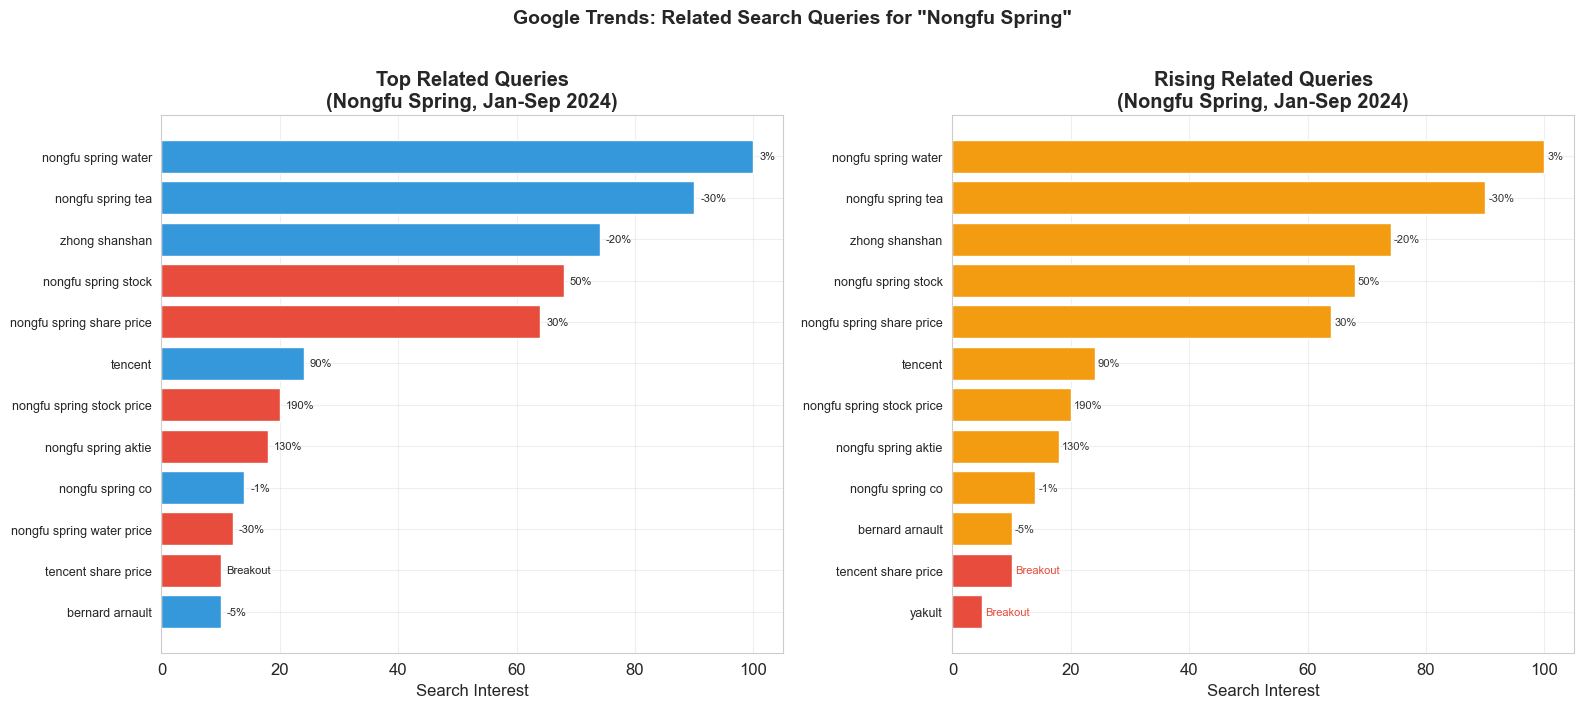

In [13]:
nf_top = pd.read_csv('data/nongfu_top_queries.csv')
nf_rise = pd.read_csv('data/nongfu_rising_queries.csv')
nf_top.columns = nf_rise.columns = ['query','search_interest','change_pct']

fig, (a1,a2) = plt.subplots(1,2, figsize=(16,7))
td = nf_top.head(12).sort_values('search_interest')
a1.barh(range(len(td)), td['search_interest'], color=['#E74C3C' if any(k in str(q).lower() for k in ['stock','price','aktie']) else '#3498DB' for q in td['query']])
a1.set_yticks(range(len(td))); a1.set_yticklabels(td['query'], fontsize=9)
a1.set_xlabel('Search Interest'); a1.set_title('Top Related Queries\n(Nongfu Spring, Jan-Sep 2024)', fontweight='bold')
for i,(_,r) in enumerate(td.iterrows()): a1.text(r['search_interest']+1, i, str(r['change_pct']), fontsize=8, va='center')

rd = nf_rise.head(12).sort_values('search_interest')
a2.barh(range(len(rd)), rd['search_interest'], color=['#E74C3C' if str(c)=='Breakout' else '#F39C12' for c in rd['change_pct']])
a2.set_yticks(range(len(rd))); a2.set_yticklabels(rd['query'], fontsize=9)
a2.set_xlabel('Search Interest'); a2.set_title('Rising Related Queries\n(Nongfu Spring, Jan-Sep 2024)', fontweight='bold')
for i,(_,r) in enumerate(rd.iterrows()): a2.text(r['search_interest']+0.5, i, str(r['change_pct']), fontsize=8, va='center', color='#E74C3C' if str(r['change_pct'])=='Breakout' else '#333')

plt.suptitle('Google Trends: Related Search Queries for "Nongfu Spring"', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout(); plt.savefig('figures/Fig3_NongfuSpring_Queries.png', dpi=150, bbox_inches='tight'); plt.show()

### 5.2 Case 2: Salt Panic
#### Figure 4: Search Interest vs. Salt Stock Prices

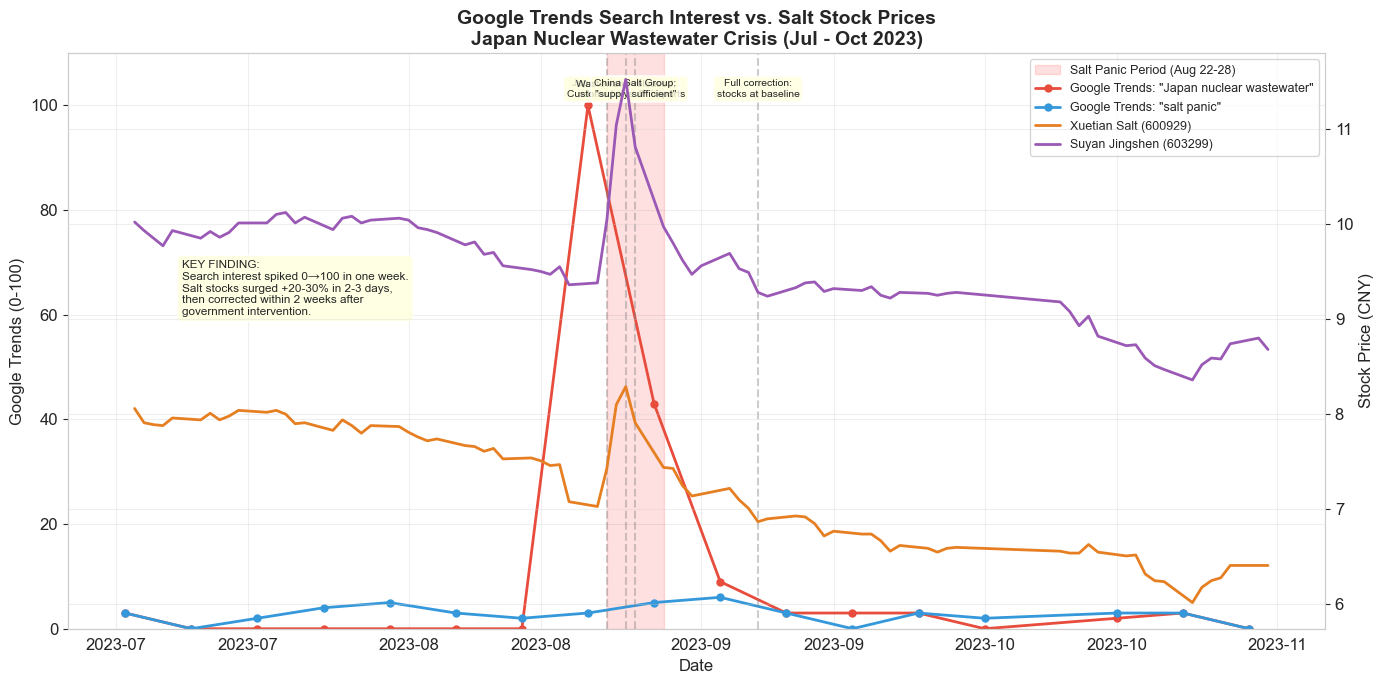

In [14]:
fig, ax1 = plt.subplots(figsize=(14, 7))
ax1.axvspan(*salt_panic, alpha=0.12, color='red', label='Salt Panic Period (Aug 22-28)')
for i,col in enumerate(salt_tcols[:2]):
    ax1.plot(salt_merged_x['date'], salt_merged_x[col], '-o', color=['#E74C3C','#3498DB'][i],
             markersize=5, linewidth=2, label=f'Google Trends: "{col}"')
ax1.set_ylabel('Google Trends (0-100)'); ax1.set_ylim(0,110)

ax2 = ax1.twinx()
ax2.plot(xuetian_stock['date'], xuetian_stock['close'], '-', color='#E67E22', linewidth=2, label='Xuetian Salt (600929)')
ax2.plot(suyan_stock['date'], suyan_stock['close'], '-', color='#9B59B6', linewidth=2, label='Suyan Jingshen (603299)')
ax2.set_ylabel('Stock Price (CNY)')

ax1.annotate('KEY FINDING:\nSearch interest spiked 0\u2192100 in one week.\nSalt stocks surged +20-30% in 2-3 days,\nthen corrected within 2 weeks after\ngovernment intervention.',
            xy=(pd.Timestamp('2023-07-08'), 60), fontsize=8.5,
            bbox=dict(boxstyle='round,pad=0.4', facecolor='lightyellow', alpha=0.9))
for ds, label in salt_events.items():
    dt = pd.Timestamp(ds)
    ax1.axvline(x=dt, color='gray', linestyle='--', alpha=0.4)
    ax1.annotate(label, xy=(dt, 105), fontsize=7.5, ha='center', va='top',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', alpha=0.8))
h1,l1 = ax1.get_legend_handles_labels(); h2,l2 = ax2.get_legend_handles_labels()
ax1.legend(h1+h2, l1+l2, loc='upper right', fontsize=9)
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m')); ax1.set_xlabel('Date')
plt.title('Google Trends Search Interest vs. Salt Stock Prices\nJapan Nuclear Wastewater Crisis (Jul - Oct 2023)', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.savefig('figures/Fig4_SaltPanic_Trends_vs_Stocks.png', dpi=150, bbox_inches='tight'); plt.show()

#### Figure 5: Salt Stock Prices & Volume

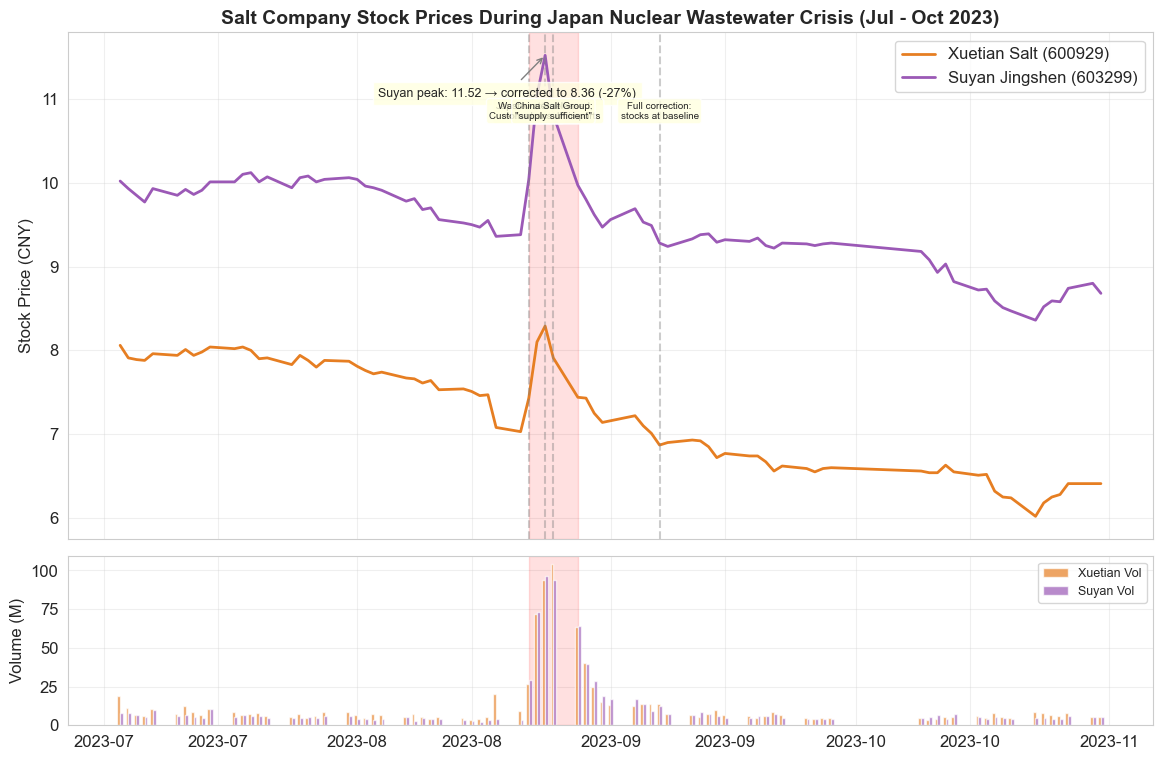

In [15]:
fig, (ap, av) = plt.subplots(2,1, figsize=(14,9), height_ratios=[3,1], sharex=True, gridspec_kw={'hspace':0.05})
for ax in [ap,av]: ax.axvspan(*salt_panic, alpha=0.12, color='red')
ap.plot(xuetian_stock['date'], xuetian_stock['close'], color='#E67E22', linewidth=2, label='Xuetian Salt (600929)')
ap.plot(suyan_stock['date'], suyan_stock['close'], color='#9B59B6', linewidth=2, label='Suyan Jingshen (603299)')
ap.set_ylabel('Stock Price (CNY)'); ap.legend(loc='upper right')

sm, sd = suyan_stock['close'].max(), suyan_stock.loc[suyan_stock['close'].idxmax(),'date']
sc = suyan_stock[suyan_stock['date']>pd.Timestamp('2023-09-01')]['close'].min()
ap.annotate(f'Suyan peak: {sm:.2f} \u2192 corrected to {sc:.2f} (-{(1-sc/sm)*100:.0f}%)',
           xy=(sd, sm), xytext=(-120,-30), textcoords='offset points', fontsize=9,
           bbox=dict(facecolor='lightyellow', alpha=0.8), arrowprops=dict(arrowstyle='->', color='gray'))
for ds, label in salt_events.items():
    dt = pd.Timestamp(ds); ap.axvline(x=dt, color='gray', linestyle='--', alpha=0.4)
    ap.annotate(label, xy=(dt, ap.get_ylim()[1]*0.93), fontsize=7, ha='center', va='top',
              bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', alpha=0.8))

w=0.35
av.bar(xuetian_stock['date']-pd.Timedelta(hours=4), xuetian_stock['volume']/1e6, width=w, color='#E67E22', alpha=0.7, label='Xuetian Vol')
av.bar(suyan_stock['date']+pd.Timedelta(hours=4), suyan_stock['volume']/1e6, width=w, color='#9B59B6', alpha=0.7, label='Suyan Vol')
av.set_ylabel('Volume (M)'); av.legend(fontsize=9)
ap.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ap.set_title('Salt Company Stock Prices During Japan Nuclear Wastewater Crisis (Jul - Oct 2023)', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.savefig('figures/Fig5_SaltPanic_Price_Volume.png', dpi=150, bbox_inches='tight'); plt.show()

#### Figure 6: Related Search Queries (Salt)

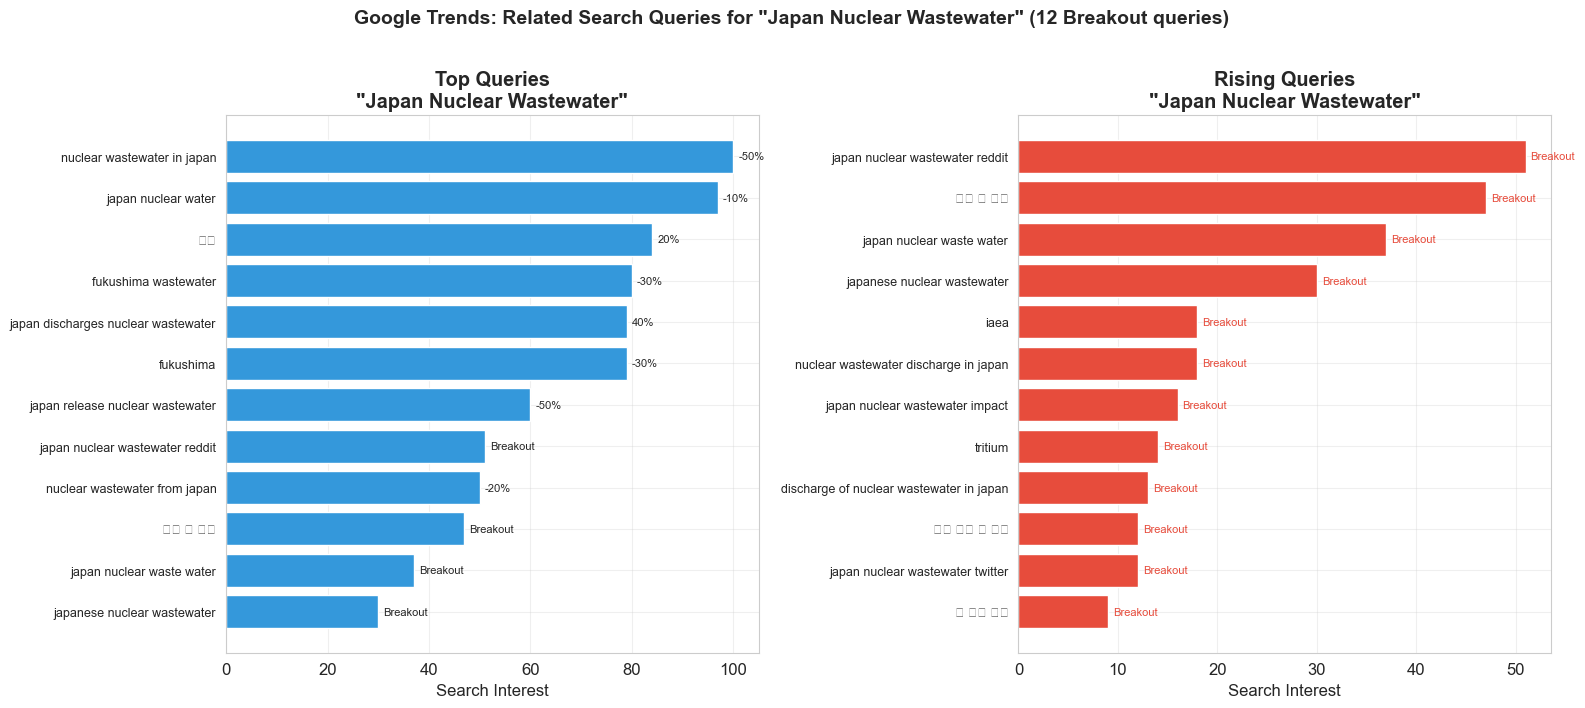

In [16]:
st_top = pd.read_csv('data/salt_top_queries.csv')
st_rise = pd.read_csv('data/salt_rising_queries.csv')
st_top.columns = st_rise.columns = ['query','search_interest','change_pct']

fig, (a1,a2) = plt.subplots(1,2, figsize=(16,7))
td = st_top.head(12).sort_values('search_interest')
a1.barh(range(len(td)), td['search_interest'], color='#3498DB')
a1.set_yticks(range(len(td))); a1.set_yticklabels(td['query'], fontsize=9)
a1.set_xlabel('Search Interest'); a1.set_title('Top Queries\n"Japan Nuclear Wastewater"', fontweight='bold')
for i,(_,r) in enumerate(td.iterrows()): a1.text(r['search_interest']+1, i, str(r['change_pct']), fontsize=8, va='center')

rd = st_rise.head(12).sort_values('search_interest')
a2.barh(range(len(rd)), rd['search_interest'], color=['#E74C3C' if str(c)=='Breakout' else '#F39C12' for c in rd['change_pct']])
a2.set_yticks(range(len(rd))); a2.set_yticklabels(rd['query'], fontsize=9)
a2.set_xlabel('Search Interest'); a2.set_title('Rising Queries\n"Japan Nuclear Wastewater"', fontweight='bold')
for i,(_,r) in enumerate(rd.iterrows()): a2.text(r['search_interest']+0.5, i, str(r['change_pct']), fontsize=8, va='center', color='#E74C3C' if str(r['change_pct'])=='Breakout' else '#333')

n_bo = (st_rise['change_pct']=='Breakout').sum()
plt.suptitle(f'Google Trends: Related Search Queries for "Japan Nuclear Wastewater" ({n_bo} Breakout queries)', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout(); plt.savefig('figures/Fig6_SaltPanic_Queries.png', dpi=150, bbox_inches='tight'); plt.show()

## 6. Statistical Analysis

### 6.1 Descriptive Statistics

In [17]:
def crisis_summary(stock_df, name, cs, ce):
    pre = stock_df[stock_df['date'] < cs]
    dur = stock_df[(stock_df['date'] >= cs) & (stock_df['date'] <= ce)]
    post = stock_df[stock_df['date'] > ce]
    pk, tr = stock_df['close'].max(), stock_df['close'].min()
    print(f"\n{'='*60}")
    print(f"{name}")
    print(f"{'='*60}")
    print(f"Pre-crisis avg:  {pre['close'].mean():.2f}  |  Crisis avg: {dur['close'].mean():.2f}  |  Post avg: {post['close'].mean():.2f}")
    print(f"Peak: {pk:.2f}  |  Trough: {tr:.2f}  |  Max decline: {((tr-pk)/pk*100):.1f}%")
    if len(pre)>0 and pre['volume'].mean()>0:
        print(f"Volume: pre {pre['volume'].mean()/1e6:.1f}M -> crisis {dur['volume'].mean()/1e6:.1f}M ({((dur['volume'].mean()/pre['volume'].mean()-1)*100):.0f}% increase)")

crisis_summary(nongfu_stock, 'Nongfu Spring (09633.HK)', *nongfu_crisis)
crisis_summary(xuetian_stock, 'Xuetian Salt (600929.SS)', *salt_panic)
crisis_summary(suyan_stock, 'Suyan Jingshen (603299.SS)', *salt_panic)


Nongfu Spring (09633.HK)
Pre-crisis avg:  42.25  |  Crisis avg: 43.03  |  Post avg: 29.95
Peak: 47.95  |  Trough: 24.35  |  Max decline: -49.2%
Volume: pre 4.2M -> crisis 4.6M (10% increase)

Xuetian Salt (600929.SS)
Pre-crisis avg:  7.78  |  Crisis avg: 7.83  |  Post avg: 6.66
Peak: 8.29  |  Trough: 6.02  |  Max decline: -27.4%
Volume: pre 7.7M -> crisis 72.0M (835% increase)

Suyan Jingshen (603299.SS)
Pre-crisis avg:  9.85  |  Crisis avg: 10.68  |  Post avg: 9.10
Peak: 11.52  |  Trough: 8.36  |  Max decline: -27.4%
Volume: pre 5.2M -> crisis 71.5M (1282% increase)


### 6.2 Correlation Analysis


Correlation: Nongfu Spring
Pearson r=-0.0205 (p=0.9002)  |  Spearman rho=-0.0010 (p=0.9952)
Best lag: 6 weeks, r=0.0547 (p=0.7585)


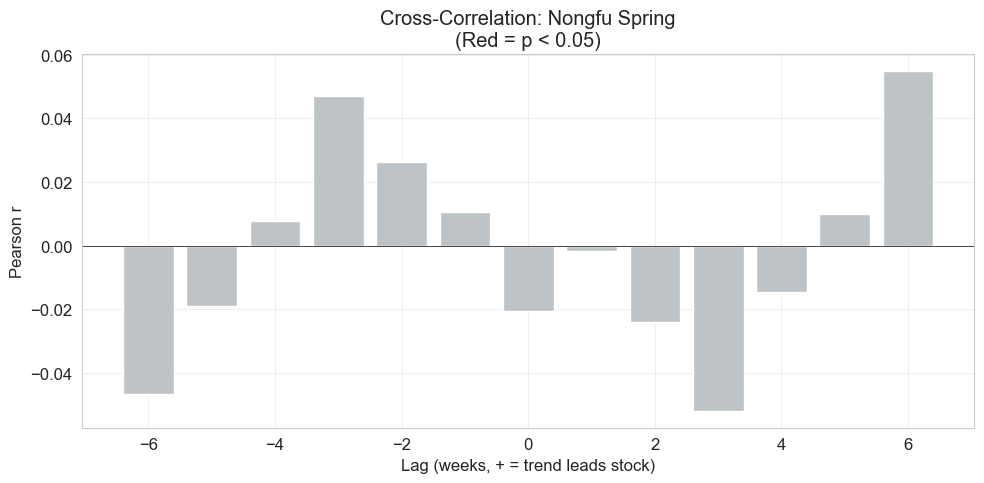


Correlation: Salt Panic (Xuetian)
Pearson r=0.1047 (p=0.6893)  |  Spearman rho=-0.2448 (p=0.3436)
Best lag: -5 weeks, r=0.4020 (p=0.1951)


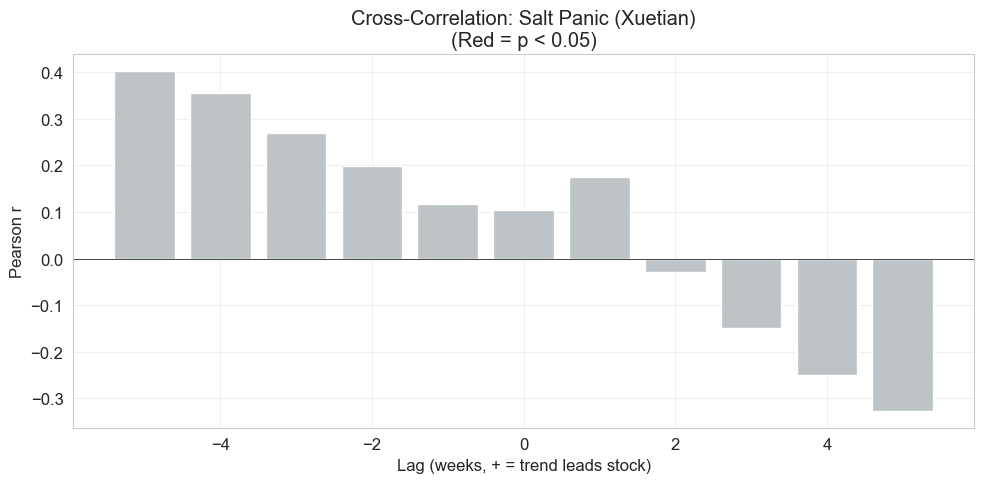

In [18]:
def correlation_analysis(mdf, tcol, scol='avg_close', name='Case'):
    v = mdf[[tcol, scol]].dropna()
    pr, pp = stats.pearsonr(v[tcol], v[scol])
    sr, sp = stats.spearmanr(v[tcol], v[scol])
    print(f"\n{'='*55}")
    print(f"Correlation: {name}")
    print(f"Pearson r={pr:.4f} (p={pp:.4f}){'*' if pp<0.05 else ''}  |  Spearman rho={sr:.4f} (p={sp:.4f}){'*' if sp<0.05 else ''}")
    
    ml = min(6, len(v)//3)
    lags = []
    for lag in range(-ml, ml+1):
        x = v[tcol].iloc[max(0,-lag):len(v)-max(0,lag)].values
        y = v[scol].iloc[max(0,lag):len(v)-max(0,-lag)].values
        if len(x)>3:
            r,p = stats.pearsonr(x,y)
            lags.append({'lag':lag,'r':r,'p':p})
    ldf = pd.DataFrame(lags)
    best = ldf.loc[ldf['r'].abs().idxmax()]
    print(f"Best lag: {int(best['lag'])} weeks, r={best['r']:.4f} (p={best['p']:.4f})")
    
    fig,ax = plt.subplots(figsize=(10,5))
    ax.bar(ldf['lag'], ldf['r'], color=['#E74C3C' if p<0.05 else '#BDC3C7' for p in ldf['p']])
    ax.axhline(y=0, color='black', linewidth=0.5)
    ax.set_xlabel('Lag (weeks, + = trend leads stock)'); ax.set_ylabel('Pearson r')
    ax.set_title(f'Cross-Correlation: {name}\n(Red = p < 0.05)')
    plt.tight_layout(); plt.savefig(f'figures/XCorr_{name.replace(" ","_")}.png', dpi=150); plt.show()
    return ldf

lag_nf = correlation_analysis(nongfu_merged, nongfu_tcols[0], name='Nongfu Spring')
lag_st = correlation_analysis(salt_merged_x, salt_tcols[0], name='Salt Panic (Xuetian)')

### 6.3 Granger Causality Test

- **H0**: Search interest does NOT Granger-cause stock price
- **H1**: Search interest DOES Granger-cause stock price
- Reject H0 if p < 0.05

In [19]:
def check_stat(s, name):
    r = adfuller(s.dropna(), autolag='AIC')
    ok = r[1]<0.05
    print(f"  ADF {name}: stat={r[0]:.3f}, p={r[1]:.4f} -> {'Stationary' if ok else 'Non-stationary (diff)'}")
    return ok

def granger_test(mdf, tcol, scol='avg_close', ml=4, name='Case'):
    print(f"\n{'='*60}")
    print(f"Granger Causality: {name} (n={len(mdf.dropna(subset=[tcol,scol]))})")
    print(f"{'='*60}")
    df = mdf[[tcol,scol]].dropna().copy()
    tu, su = tcol, scol
    if not check_stat(df[tcol], tcol): df[tcol+'_d']=df[tcol].diff(); tu=tcol+'_d'
    if not check_stat(df[scol], scol): df[scol+'_d']=df[scol].diff(); su=scol+'_d'
    df = df.dropna()
    if len(df)<ml+5: ml=max(1,len(df)//4); print(f"  Reduced max_lag to {ml}")
    
    print(f"\nForward: {tcol} -> {scol}")
    try:
        rf = grangercausalitytests(df[[su,tu]].values, maxlag=ml, verbose=False)
        for lag in range(1,ml+1):
            f,p = rf[lag][0]['ssr_ftest'][:2]
            print(f"  Lag {lag}: F={f:.3f}, p={p:.4f} {'YES' if p<0.05 else 'no'}")
    except Exception as e: print(f"  Error: {e}")
    
    print(f"\nReverse: {scol} -> {tcol}")
    try:
        rr = grangercausalitytests(df[[tu,su]].values, maxlag=ml, verbose=False)
        for lag in range(1,ml+1):
            f,p = rr[lag][0]['ssr_ftest'][:2]
            print(f"  Lag {lag}: F={f:.3f}, p={p:.4f} {'YES' if p<0.05 else 'no'}")
    except Exception as e: print(f"  Error: {e}")

granger_test(nongfu_merged, nongfu_tcols[0], ml=4, name='Nongfu Spring')
granger_test(salt_merged_x, salt_tcols[0], ml=3, name='Salt Panic (Xuetian)')
granger_test(salt_merged_s, salt_tcols[0], ml=3, name='Salt Panic (Suyan)')


Granger Causality: Nongfu Spring (n=40)
  ADF Nongfu Spring: stat=-4.593, p=0.0001 -> Stationary
  ADF avg_close: stat=-0.105, p=0.9490 -> Non-stationary (diff)

Forward: Nongfu Spring -> avg_close
  Lag 1: F=0.587, p=0.4488 no
  Lag 2: F=1.067, p=0.3558 no
  Lag 3: F=0.868, p=0.4686 no
  Lag 4: F=1.050, p=0.4006 no

Reverse: avg_close -> Nongfu Spring
  Lag 1: F=0.007, p=0.9348 no
  Lag 2: F=0.001, p=0.9989 no
  Lag 3: F=0.430, p=0.7333 no
  Lag 4: F=0.299, p=0.8757 no

Granger Causality: Salt Panic (Xuetian) (n=17)
  ADF Japan nuclear wastewater: stat=-2.759, p=0.0643 -> Non-stationary (diff)
  ADF avg_close: stat=0.357, p=0.9798 -> Non-stationary (diff)

Forward: Japan nuclear wastewater -> avg_close
  Lag 1: F=43.747, p=0.0000 YES
  Lag 2: F=32.227, p=0.0001 YES
  Lag 3: F=15.953, p=0.0029 YES

Reverse: avg_close -> Japan nuclear wastewater
  Lag 1: F=0.696, p=0.4204 no
  Lag 2: F=0.032, p=0.9685 no
  Lag 3: F=0.184, p=0.9037 no

Granger Causality: Salt Panic (Suyan) (n=17)
  ADF 

### 6.4 Event Study: Cumulative Abnormal Returns

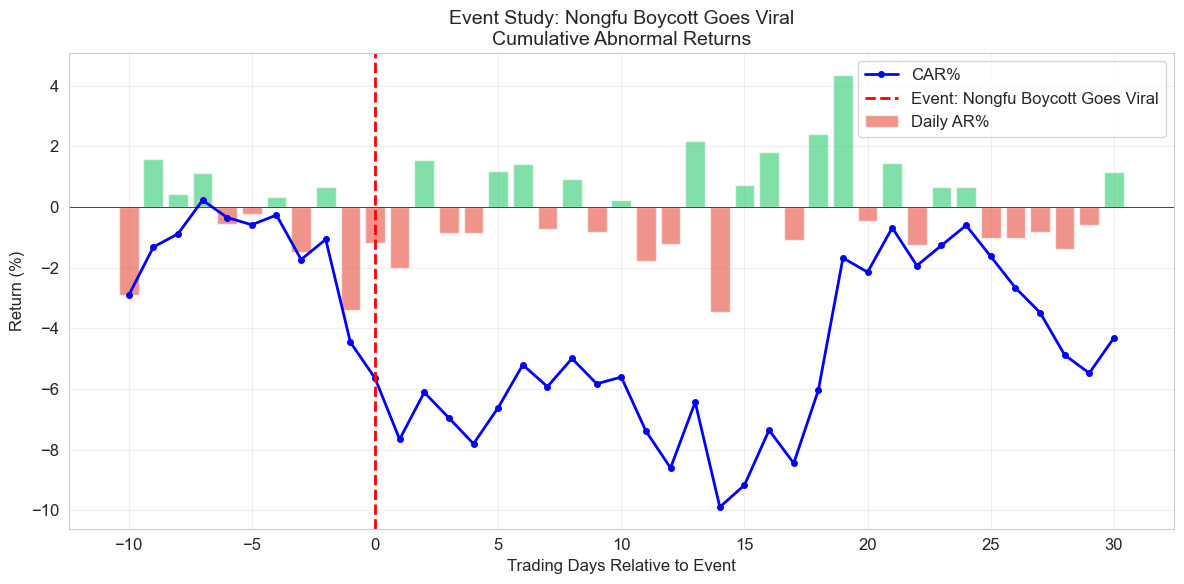

CAR at day +30: -4.32%


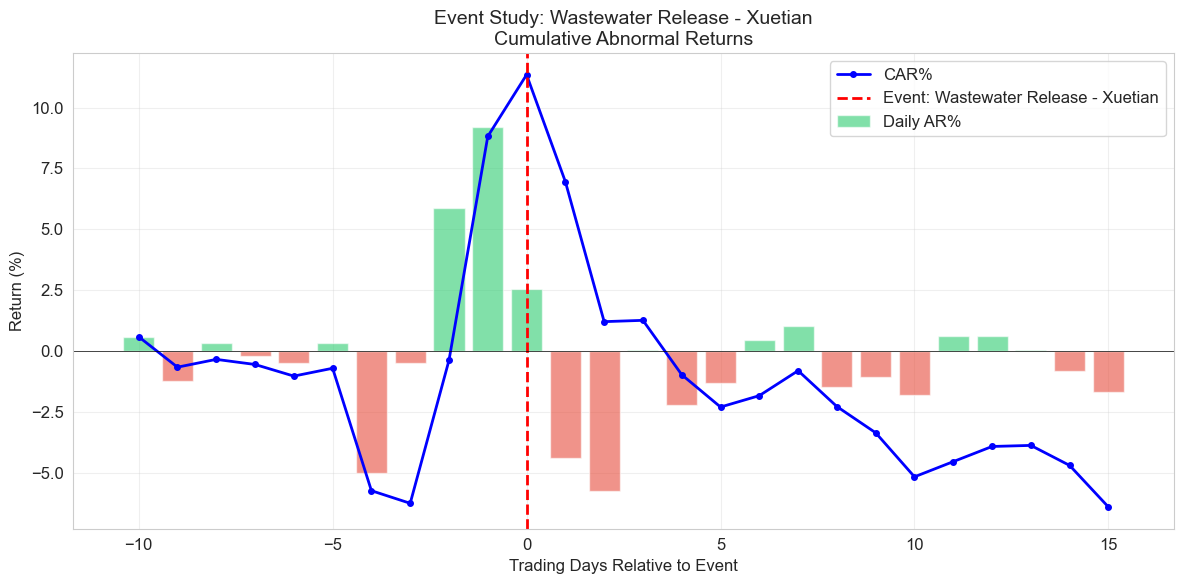

CAR at day +15: -6.42%


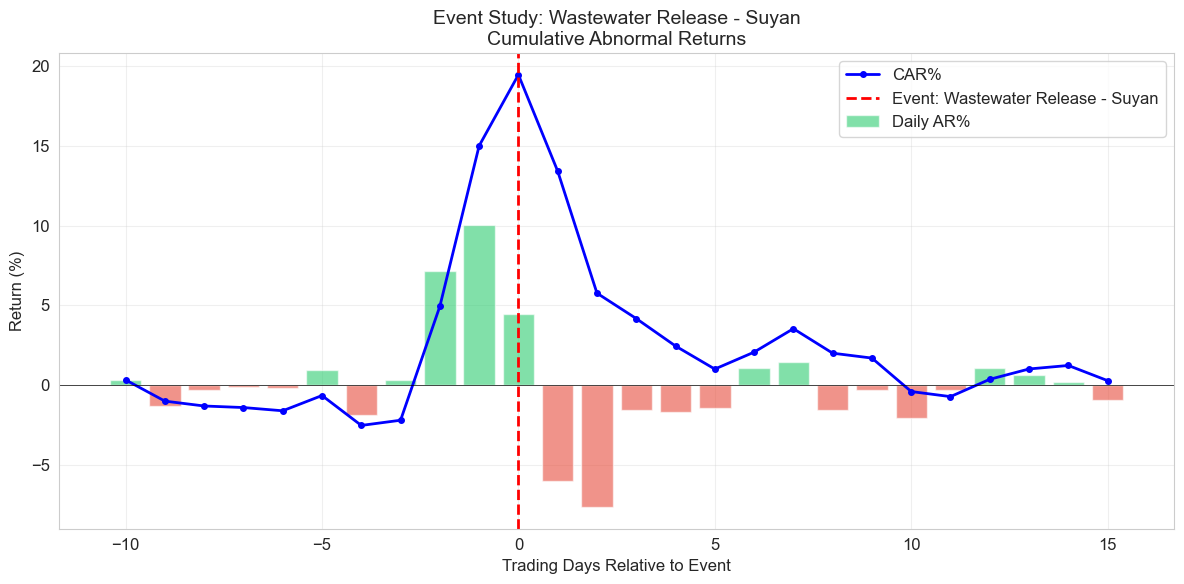

CAR at day +15: 0.27%


In [20]:
def event_study(sdf, edate, ename, wb=10, wa=20):
    edt = pd.Timestamp(edate); df = sdf.copy()
    ei = df[df['date']>=edt].index[0]
    nr = df.loc[max(0,ei-wb-30):ei-wb, 'daily_return'].mean()
    w = df.loc[max(0,ei-wb):min(len(df)-1,ei+wa)].copy()
    w['ar'] = w['daily_return'] - nr
    w['CAR'] = w['ar'].cumsum()
    w['day'] = range(-min(wb,ei-w.index[0]), len(w)-min(wb,ei-w.index[0]))
    
    fig,ax = plt.subplots(figsize=(12,6))
    ax.bar(w['day'], w['ar']*100, color=['#E74C3C' if x<0 else '#2ECC71' for x in w['ar']], alpha=0.6, label='Daily AR%')
    ax.plot(w['day'], w['CAR']*100, 'b-o', linewidth=2, markersize=4, label='CAR%')
    ax.axvline(x=0, color='red', linestyle='--', linewidth=2, label=f'Event: {ename}')
    ax.axhline(y=0, color='black', linewidth=0.5)
    ax.set_xlabel('Trading Days Relative to Event'); ax.set_ylabel('Return (%)')
    ax.set_title(f'Event Study: {ename}\nCumulative Abnormal Returns', fontsize=14); ax.legend()
    plt.tight_layout(); plt.savefig(f'figures/ES_{ename.replace(" ","_")}.png', dpi=150); plt.show()
    print(f"CAR at day +{wa}: {w['CAR'].iloc[-1]*100:.2f}%")
    return w

es1 = event_study(nongfu_stock, '2024-03-03', 'Nongfu Boycott Goes Viral', wa=30)
es2 = event_study(xuetian_stock, '2023-08-24', 'Wastewater Release - Xuetian', wb=10, wa=15)
es3 = event_study(suyan_stock, '2023-08-24', 'Wastewater Release - Suyan', wb=10, wa=15)

## 7. Cross-Case Comparison

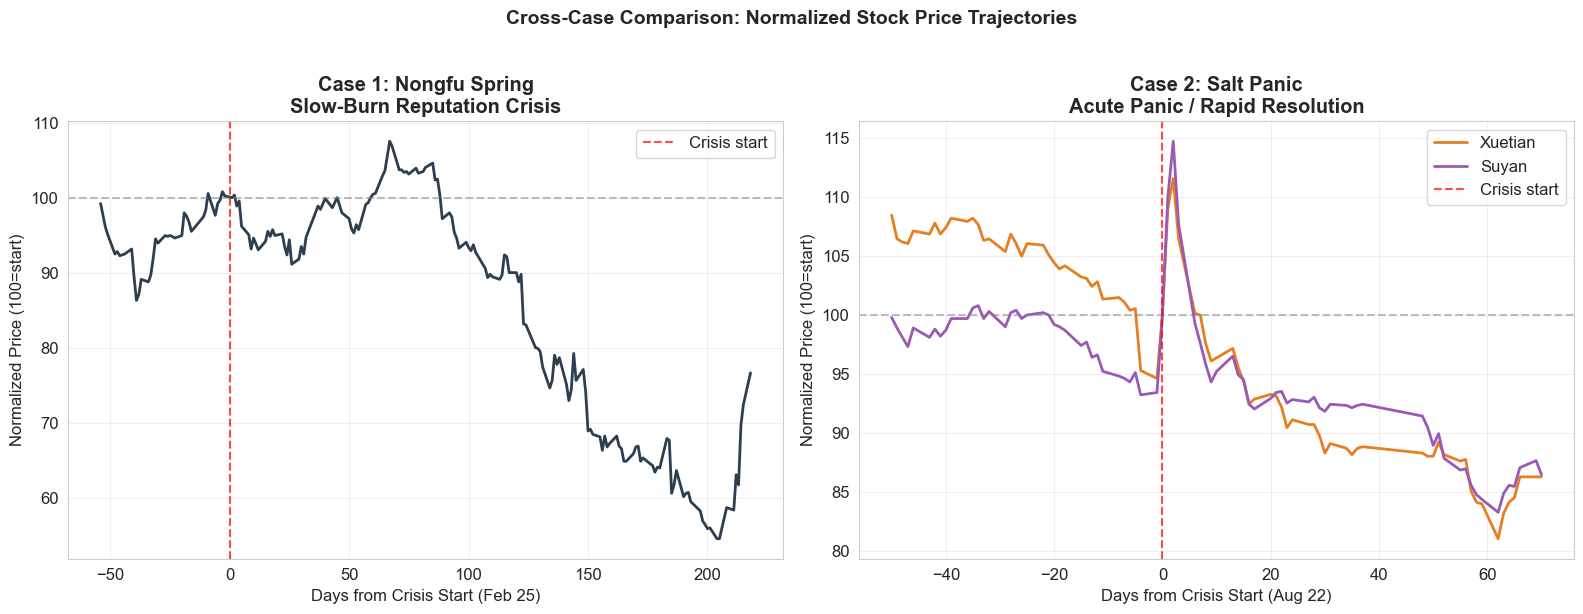

In [21]:
# Normalized price trajectories from crisis onset
fig, (a1,a2) = plt.subplots(1,2, figsize=(16,6))

ns = nongfu_stock.copy()
p0 = ns[ns['date']>=nongfu_crisis[0]].iloc[0]['close']
ns['norm'] = ns['close']/p0*100
ns['d'] = (ns['date']-nongfu_crisis[0]).dt.days
a1.plot(ns['d'], ns['norm'], color='#2C3E50', linewidth=2)
a1.axhline(y=100, color='gray', linestyle='--', alpha=0.5)
a1.axvline(x=0, color='red', linestyle='--', alpha=0.7, label='Crisis start')
a1.set_xlabel('Days from Crisis Start (Feb 25)'); a1.set_ylabel('Normalized Price (100=start)')
a1.set_title('Case 1: Nongfu Spring\nSlow-Burn Reputation Crisis', fontweight='bold'); a1.legend()

for sdf, nm, c in [(xuetian_stock,'Xuetian','#E67E22'),(suyan_stock,'Suyan','#9B59B6')]:
    s = sdf.copy(); p0 = s[s['date']>=salt_panic[0]].iloc[0]['close']
    s['norm'] = s['close']/p0*100; s['d'] = (s['date']-salt_panic[0]).dt.days
    a2.plot(s['d'], s['norm'], color=c, linewidth=2, label=nm)
a2.axhline(y=100, color='gray', linestyle='--', alpha=0.5)
a2.axvline(x=0, color='red', linestyle='--', alpha=0.7, label='Crisis start')
a2.set_xlabel('Days from Crisis Start (Aug 22)'); a2.set_ylabel('Normalized Price (100=start)')
a2.set_title('Case 2: Salt Panic\nAcute Panic / Rapid Resolution', fontweight='bold'); a2.legend()

plt.suptitle('Cross-Case Comparison: Normalized Stock Price Trajectories', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout(); plt.savefig('figures/Fig7_CrossCase_Comparison.png', dpi=150, bbox_inches='tight'); plt.show()

In [22]:
comp = pd.DataFrame({
    'Dimension': ['Crisis Duration','Trigger','Peak Search Interest','Max Stock Decline',
                  'Recovery','Gov Intervention','Gov Response Lag','Archetype'],
    'Nongfu Spring (2024)': ['~6 months','Rival founder death -> boycott',
        f'{nongfu_merged[nongfu_tcols[0]].max()} ({nongfu_merged[nongfu_tcols[0]].max()/max(1,nongfu_merged[nongfu_tcols[0]].iloc[:4].mean()):.1f}x)',
        f'{((nongfu_stock["close"].min()-nongfu_stock["close"].max())/nongfu_stock["close"].max()*100):.1f}%',
        'No full recovery','Indirect only','N/A','Slow-burn reputation'],
    'Salt Panic (2023)': ['~2 weeks','Fukushima release -> panic buying',
        f'{salt_merged_x[salt_tcols[0]].max()} (0->100 in 1 week)','~20% (peak to correction)',
        '~2 weeks to baseline','Direct: ban + reassurance + anti-gouging','Same day','Acute panic']
})
print(comp.to_string(index=False))

           Dimension           Nongfu Spring (2024)                        Salt Panic (2023)
     Crisis Duration                      ~6 months                                 ~2 weeks
             Trigger Rival founder death -> boycott        Fukushima release -> panic buying
Peak Search Interest                      68 (6.6x)                   100 (0->100 in 1 week)
   Max Stock Decline                         -49.2%                ~20% (peak to correction)
            Recovery               No full recovery                     ~2 weeks to baseline
    Gov Intervention                  Indirect only Direct: ban + reassurance + anti-gouging
    Gov Response Lag                            N/A                                 Same day
           Archetype           Slow-burn reputation                              Acute panic


## 8. Key Findings

**1. Social media trends precede or coincide with market movements** in both cases.

**2. Crisis dynamics differ by type**: reputation crises (Nongfu) are slow-burn with persistent effects; panic crises (salt) are acute with rapid resolution.

**3. Government intervention shapes outcomes**: swift multi-level response contained the salt panic in 2 weeks; absence of intervention let Nongfu's decline persist for months.

**4. China's regulated environment creates distinct threshold dynamics** (Kim et al. 2021): higher activation threshold, but severe spillover once crossed (King et al. 2013).

### Limitations
- Google Trends as proxy for Chinese social media (Weibo/Douyin APIs unavailable)
- Weekly granularity may miss intra-week dynamics
- Two cases limit generalizability
- Granger causality != true causation

## 9. Appendix

In [23]:
import sys; import statsmodels; import scipy
print(f"Python {sys.version}\npandas {pd.__version__}\nnumpy {np.__version__}")
print(f"matplotlib {plt.matplotlib.__version__}\nstatsmodels {statsmodels.__version__}\nscipy {scipy.__version__}\nseaborn {sns.__version__}")

Python 3.13.5 | packaged by Anaconda, Inc. | (main, Jun 12 2025, 11:23:37) [Clang 14.0.6 ]
pandas 2.3.3
numpy 2.3.5
matplotlib 3.10.7
statsmodels 0.14.6
scipy 1.16.3
seaborn 0.13.2
